In [1]:
## Figure S4

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm


from scipy.stats import linregress

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable


from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [3]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)


## Ocean Mask

In [4]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-20,20))
#ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi
ocean_mask = masks.seamask # all tropical oceans


In [5]:
composite_years = [1982, 1987, 1991, 1997, 2015, 2009]


## W500

In [6]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(20, -20))#,lon= slice(110, 260))

w500 = w500.where(ocean_mask)


In [7]:
w500 = w500.where((w500.time.dt.month<=9)& (w500.time.dt.month>=4)).groupby('time.year').mean('time')
w2023 = w500.sel(year = 2023)
wcomposite = w500.where(w500.year.isin(composite_years), drop = True).mean('year')
wdiff = w500.where(w500.year.isin(composite_years), drop = True).mean('year')


## CERES

In [8]:
fp = '/data/jmex/CERES/CERES_TOA.nc'
ceres = xr.open_dataset(fp).where(ocean_mask)

clim = ceres.sel(time = slice('1991', '2020')).groupby('time.month').mean()
ceres_anom = ceres.groupby('time.month') - clim
ceres_anom = ceres_anom.rolling(time = 3, center = True, min_periods = 1).mean()

In [9]:
y = 2023
sel1 = ceres_anom.sel(time = str(y)).where((ceres_anom.time.dt.month<=9)&(ceres_anom.time.dt.month>=4)).mean('time')
sel2 = ceres_anom.sel(time = str(y-1)).where((ceres_anom.time.dt.month<=9)&(ceres_anom.time.dt.month>=4)).mean('time')

delta_ceres = sel1-sel2

/tmp/ipykernel_2909319/4089732914.py:40: UserWarning: linewidths is ignored by contourf
  ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,


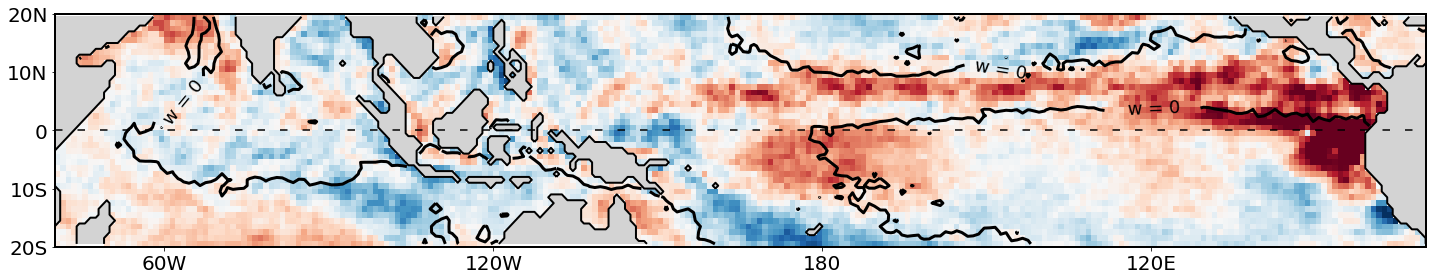

In [10]:
fig, ax = plt.subplots(1,1, figsize = (20,4))


norm = mcolors.Normalize(vmin = -20, vmax = 20)

# Apply the colormap with the BoundaryNorm

cbar = delta_ceres.toa_net_all_mon.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=ax, 
    add_colorbar=False
)

CS1 = w2023.w.plot.contour(levels=[-0.0], ax=ax, colors = 'k', linewidths = 3)
ax.clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
ax.set_title('')
#plt.colorbar(cbar, ax = ax, label = 'N Change [W/m2]')


#fig.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')


for ax in [ax]: 
    ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    
    xtick_position = [60, 120, 180, 240] 
    xtick_labels = [ '60W', '120W', '180', '120E']
    ax.set_xticks(ticks = xtick_position,)
    ax.set_xticklabels(xtick_labels, fontsize = 20)
    ax.set_yticklabels(['20S', '10S', '0', '10N', '20N'], fontsize=20)
    
    #ax.spines[:].set_visible(False)
    ax.spines[:].set_linewidth(2)

#contours for ocean
ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0,0.5], colors='lightgrey', linewidths=2)
ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0.5], colors='k', linewidths=2)

ax.axhline(0, linestyle=(0, (5, 10)), c = 'k')



plt.tight_layout()
plt.savefig('output/FigS4.pdf', bbox_inches = 'tight')


/tmp/ipykernel_2909319/1772469718.py:1: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')


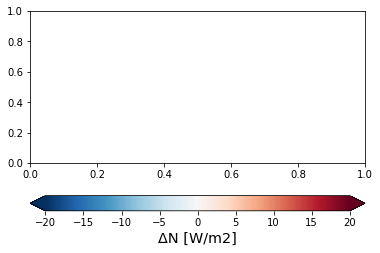

In [13]:
plt.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')
plt.savefig('output/FigS4cbar.svg', bbox_inches = 'tight')


